In [1]:
import numpy as np
import adi

# ----------------------------
# DSP helpers (no SciPy needed)
# ----------------------------

def design_lowpass_fir(cutoff_hz, fs_hz, num_taps=129, window="hann"):
    """
    Windowed-sinc lowpass FIR, normalized to DC gain = 1.
    cutoff_hz: lowpass cutoff (Hz)
    fs_hz: sample rate (Hz)
    """
    if cutoff_hz <= 0 or cutoff_hz >= fs_hz / 2:
        raise ValueError("cutoff_hz must be between 0 and Nyquist.")

    n = np.arange(num_taps, dtype=np.float64)
    m = (num_taps - 1) / 2.0
    fc = cutoff_hz / fs_hz  # normalized (cycles/sample)

    # ideal sinc lowpass: 2*fc*sinc(2*fc*(n-m))
    h = 2.0 * fc * np.sinc(2.0 * fc * (n - m))

    # window
    if window == "hann":
        w = 0.5 - 0.5 * np.cos(2.0 * np.pi * n / (num_taps - 1))
    elif window == "hamming":
        w = 0.54 - 0.46 * np.cos(2.0 * np.pi * n / (num_taps - 1))
    elif window == "blackman":
        w = 0.42 - 0.5 * np.cos(2.0 * np.pi * n / (num_taps - 1)) + 0.08 * np.cos(4.0 * np.pi * n / (num_taps - 1))
    else:
        raise ValueError("Unsupported window. Use 'hann', 'hamming', or 'blackman'.")

    h *= w

    # normalize DC gain
    h /= np.sum(h)

    return h.astype(np.float64)

In [2]:
def ddc_extract(iq, fs_hz, f_offset_hz, out_bw_hz, decim, fir_taps=129):
    """
    Digital downconvert a subchannel:
      1) Mix by exp(-j2π f_offset t) to move signal at f_offset to DC
      2) Lowpass filter to out_bw_hz/2 (ish)
      3) Decimate by integer factor

    iq: complex64/complex128 input samples
    fs_hz: input sample rate
    f_offset_hz: (f_target - f_lo). Example: -22.5e6
    out_bw_hz: desired channel bandwidth (Hz)
    decim: integer decimation factor
    """
    iq = np.asarray(iq)
    n = np.arange(iq.size, dtype=np.float64)
    t = n / float(fs_hz)

    # Mix: signal at f_offset -> DC
    mixer = np.exp(-1j * 2.0 * np.pi * float(f_offset_hz) * t)
    mixed = iq * mixer

    # Lowpass: use cutoff slightly above half the desired BW
    # (guard factor helps with transition band)
    cutoff = 0.6 * (out_bw_hz / 2.0)
    if cutoff <= 0:
        raise ValueError("out_bw_hz must be > 0.")

    h = design_lowpass_fir(cutoff_hz=cutoff, fs_hz=fs_hz, num_taps=fir_taps, window="hann")

    # FIR via convolution (same length)
    # For long captures, you may want overlap-save; this is simpler and works fine for moderate sizes.
    filt = np.convolve(mixed, h.astype(np.complex128), mode="same")

    # Decimate
    decimated = filt[::decim]

    # New sample rate:
    fs_out = fs_hz / decim
    return decimated.astype(np.complex64), fs_out

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_waterfall(iq, fs_hz, lo_hz=None, nfft=4096, hop=None, window="hann",
                   db_floor=-120, db_ceiling=-20, title="Wideband Waterfall"):
    """
    iq: complex array (wideband)
    fs_hz: sample rate
    lo_hz: if provided, x-axis is absolute RF frequency (Hz). If None, baseband (Hz).
    nfft: FFT size per slice
    hop: samples to advance per slice (defaults to nfft//4)
    """
    iq = np.asarray(iq)
    if hop is None:
        hop = nfft // 4
    if hop <= 0:
        raise ValueError("hop must be > 0")

    # Window
    if window == "hann":
        w = np.hanning(nfft)
    elif window == "hamming":
        w = np.hamming(nfft)
    else:
        raise ValueError("window must be 'hann' or 'hamming'")

    # How many time slices
    n_slices = 1 + (len(iq) - nfft) // hop if len(iq) >= nfft else 0
    if n_slices <= 0:
        raise ValueError("iq too short for chosen nfft")

    # Build spectrogram matrix: (freq_bins, time_slices)
    S = np.empty((nfft, n_slices), dtype=np.float32)

    for k in range(n_slices):
        start = k * hop
        x = iq[start:start+nfft]
        x = x - np.mean(x)  # DC remove per-slice (helps Pluto)
        X = np.fft.fftshift(np.fft.fft(x * w, n=nfft))
        P = 20.0 * np.log10(np.abs(X) + 1e-12)
        S[:, k] = P.astype(np.float32)

    # Frequency axis
    f = np.fft.fftshift(np.fft.fftfreq(nfft, d=1.0/fs_hz))  # Hz
    if lo_hz is not None:
        f_rf = f + lo_hz
        xvals = f_rf / 1e9
        xlabel = "Frequency (GHz)"
    else:
        xvals = f / 1e6
        xlabel = "Frequency offset (MHz)"

    # Time axis
    t = (np.arange(n_slices) * hop) / fs_hz  # seconds

    plt.figure()
    plt.imshow(
        S.T,
        aspect="auto",
        origin="lower",
        extent=[xvals[0], xvals[-1], t[0]*1e3, t[-1]*1e3],  # ms on y
        vmin=db_floor,
        vmax=db_ceiling,
        interpolation="nearest",
    )
    plt.colorbar(label="Magnitude (dB)")
    plt.xlabel(xlabel)
    plt.ylabel("Time (ms)")
    plt.title(title)
    plt.grid(False)
    plt.show()


def plot_psd_summary(iq, fs_hz, lo_hz=None, nfft=16384, title="Wideband PSD (median / max)"):
    """
    Computes a coarse 'over time' PSD summary:
      - median spectrum (typical level)
      - max spectrum (shows bursts)
    """
    iq = np.asarray(iq)
    if len(iq) < nfft:
        nfft = 2**int(np.floor(np.log2(len(iq))))  # largest pow2 <= len(iq)
        if nfft < 1024:
            raise ValueError("iq too short for PSD summary")

    hop = nfft // 2
    w = np.hanning(nfft)

    n_slices = 1 + (len(iq) - nfft) // hop
    specs = []

    for k in range(n_slices):
        x = iq[k*hop:k*hop+nfft]
        x = x - np.mean(x)
        X = np.fft.fftshift(np.fft.fft(x * w, n=nfft))
        P = 20*np.log10(np.abs(X) + 1e-12)
        specs.append(P)

    specs = np.array(specs)  # shape (time, freq)
    P_med = np.median(specs, axis=0)
    P_max = np.max(specs, axis=0)

    f = np.fft.fftshift(np.fft.fftfreq(nfft, d=1.0/fs_hz))  # Hz
    if lo_hz is not None:
        xvals = (f + lo_hz) / 1e9
        xlabel = "Frequency (GHz)"
    else:
        xvals = f / 1e6
        xlabel = "Frequency offset (MHz)"

    plt.figure()
    plt.plot(xvals, P_med, label="median")
    plt.plot(xvals, P_max, label="max")
    plt.xlabel(xlabel)
    plt.ylabel("Magnitude (dB)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_power_histogram(iq, title="IQ magnitude histogram (DC removed)"):
    """
    Histogram of magnitude; useful to spot clipping or strong bursts.
    """
    iq = np.asarray(iq)
    x = iq - np.mean(iq)
    mag = np.abs(x)

    plt.figure()
    plt.hist(mag, bins=200)
    plt.xlabel("|IQ|")
    plt.ylabel("Count")
    plt.title(title)
    plt.grid(True)
    plt.show()


In [4]:
# ----------------------------
# Wideband capture + 2 channels
# ----------------------------

def pluto_capture_two_rf_channels_time_coherent(
    uri="ip:pluto.local",
    f1_hz=2.405e9,
    f2_hz=2.450e9,
    sample_rate=61_440_000,       # try 61.44 MS/s
    rf_bandwidth=56_000_000,      # try ~50–56 MHz (must be supported by your build)
    gain_mode="manual",
    gain_db=20,
    num_samples=2_000_000,        # wideband: keep modest unless you know your link can stream more
    warmup_reads=2,
    chunk=262144,
    out_bw_hz=2_000_000,          # extracted channel BW (Hz) per subchannel
    decim=32,                     # 61.44e6 / 32 = 1.92 MS/s output
):
    """
    Captures ONE wideband IQ recording, then extracts two RF channels (f1, f2)
    with coherent time alignment.

    Returns:
      ch1_iq, ch2_iq, fs_out, meta
    """
    # Center LO midway
    lo_hz = 0.5 * (f1_hz + f2_hz)
    # lo_hz = f1_hz
    # lo_hz = 103e6

    # Offsets of each RF channel relative to LO (these are what appear in baseband)
    off1 = f1_hz - lo_hz  # e.g. 2.405 - 2.4275 = -22.5 MHz
    off2 = f2_hz - lo_hz  # e.g. +22.5 MHz

    sdr = adi.Pluto(uri)

    # Single RX is enough for this frequency-coherent two-channel extraction
    # (You can also enable both RX channels if you want spatial info too.)
    sdr.rx_enabled_channels = [0]

    sdr.rx_lo = int(lo_hz)
    sdr.sample_rate = int(sample_rate)
    sdr.rx_rf_bandwidth = int(rf_bandwidth)

    sdr.gain_control_mode_chan0 = gain_mode
    if gain_mode == "manual":
        sdr.rx_hardwaregain_chan0 = float(gain_db)

    sdr.rx_buffer_size = int(chunk)

    for _ in range(warmup_reads):
        _ = sdr.rx()

    # Capture wideband IQ
    iq = np.empty(num_samples, dtype=np.complex64)
    got = 0
    while got < num_samples:
        x = sdr.rx()
        x = np.asarray(x).astype(np.complex64, copy=False)

        # If somehow returns multi-chan, take chan0
        if x.ndim > 1:
            x = x[0]

        n = min(x.size, num_samples - got)
        iq[got:got+n] = x[:n]
        got += n

    print("Capture done.")
    
    # Extract two subchannels from the SAME iq stream (time-coherent)
    ch1, fs_out = ddc_extract(iq, fs_hz=sample_rate, f_offset_hz=off1, out_bw_hz=out_bw_hz, decim=decim)
    ch2, _      = ddc_extract(iq, fs_hz=sample_rate, f_offset_hz=off2, out_bw_hz=out_bw_hz, decim=decim)

    meta = {
        "lo_hz": lo_hz,
        "f1_hz": f1_hz,
        "f2_hz": f2_hz,
        "offset1_hz": off1,
        "offset2_hz": off2,
        "fs_in_hz": sample_rate,
        "fs_out_hz": fs_out,
        "rf_bandwidth_hz": rf_bandwidth,
        "decim": decim,
        "out_bw_hz": out_bw_hz,
    }
    return iq, ch1, ch2, fs_out, meta

In [5]:
sample_rate = 61_440_000
sample_time = 0.020 #0.100
num_samples = int(sample_rate * sample_time)
print(num_samples)

1228800


In [6]:
for i in range(20,25):
    print("2^{} = {:,} kB".format(i, 2**i/1024))

2^20 = 1,024.0 kB
2^21 = 2,048.0 kB
2^22 = 4,096.0 kB
2^23 = 8,192.0 kB
2^24 = 16,384.0 kB


In [7]:
if __name__ == "__main__":
    iq, ch_2405, ch_2450, fs_out, meta = pluto_capture_two_rf_channels_time_coherent(
        uri="ip:pluto.local",
        f1_hz=2.405e9,
        f2_hz=2.450e9,
        sample_rate=61_440_000,
        rf_bandwidth=56_000_000,
        # rf_bandwidth=10_000_000,
        gain_mode="manual",
        gain_db=60,
        num_samples=num_samples,
        out_bw_hz=2_000_000,
        # out_bw_hz=3_000_000,
        decim=32, #32,                # fs_out = 1.92 MS/s
        # chunk=1_048_576  #524288
        chunk=int(2**22) # 2**24 is the limit
    )

    print("Output sample rate:", fs_out)
    print("ch_2405:", ch_2405.shape, ch_2405.dtype)
    print("ch_2450:", ch_2450.shape, ch_2450.dtype)
    print("meta:", meta)

    # Simple sanity check: compute rough power in each extracted channel
    p1 = 10*np.log10(np.mean(np.abs(ch_2405)**2) + 1e-12)
    p2 = 10*np.log10(np.mean(np.abs(ch_2450)**2) + 1e-12)
    print("Power dBFS-ish (relative): 2405 =", p1, "2450 =", p2)

Capture done.
Output sample rate: 1920000.0
ch_2405: (38400,) complex64
ch_2450: (38400,) complex64
meta: {'lo_hz': 2427500000.0, 'f1_hz': 2405000000.0, 'f2_hz': 2450000000.0, 'offset1_hz': -22500000.0, 'offset2_hz': 22500000.0, 'fs_in_hz': 61440000, 'fs_out_hz': 1920000.0, 'rf_bandwidth_hz': 56000000, 'decim': 32, 'out_bw_hz': 2000000}
Power dBFS-ish (relative): 2405 = 11.217589 2450 = 26.137331


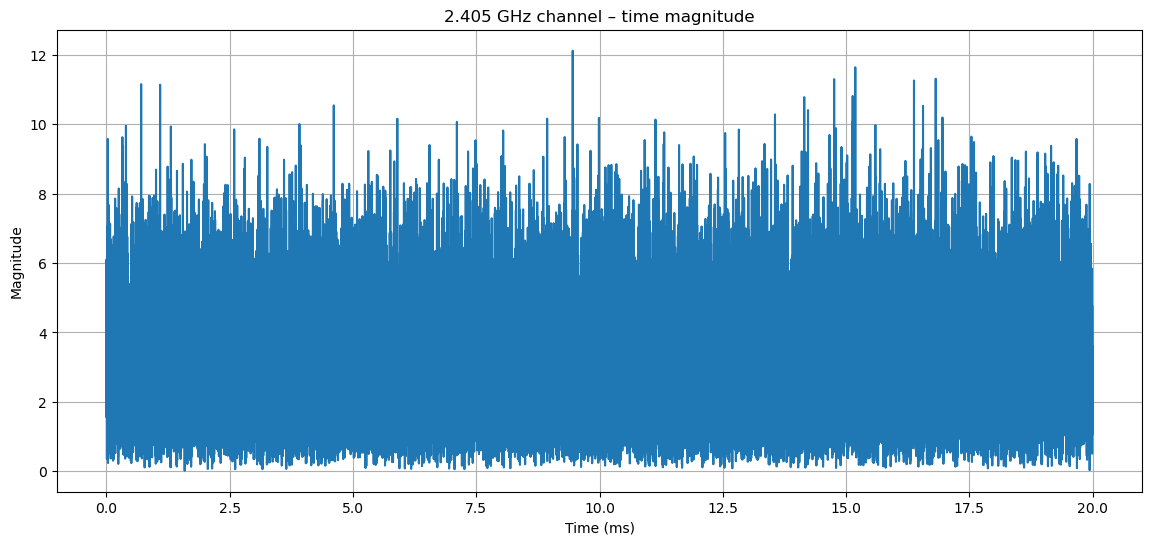

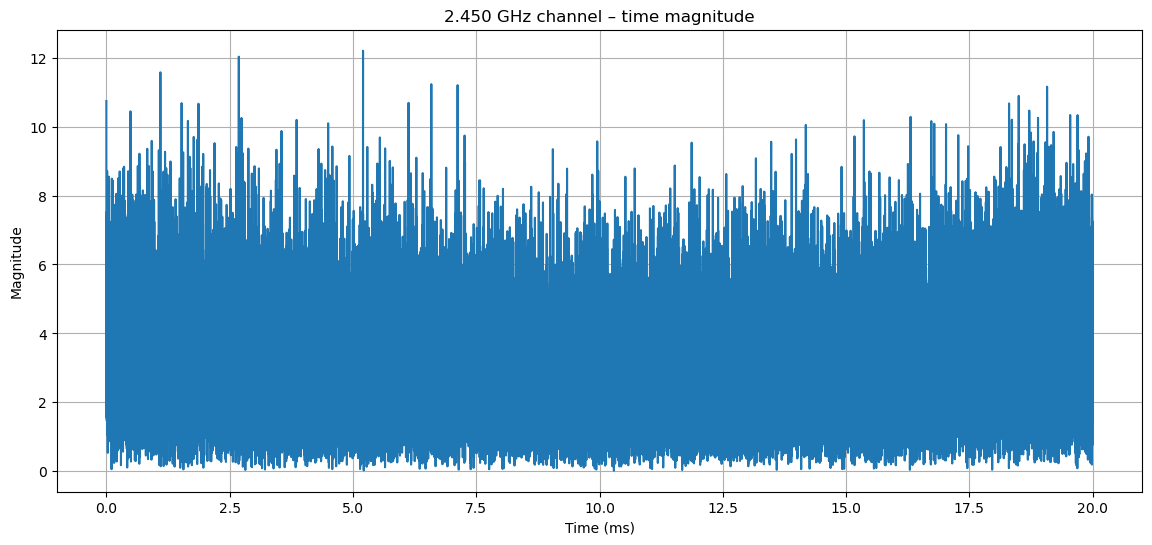

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_time_magnitude(x, fs, title):
    t = np.arange(len(x)) / fs
    mag = np.abs(x - np.mean(x))
    
    fig_size = (14, 6)
    plt.figure(figsize=fig_size)
    plt.plot(t * 1e3, mag)
    plt.xlabel("Time (ms)")
    plt.ylabel("Magnitude")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_time_magnitude(ch_2405, fs_out, "2.405 GHz channel – time magnitude")
plot_time_magnitude(ch_2450, fs_out, "2.450 GHz channel – time magnitude")

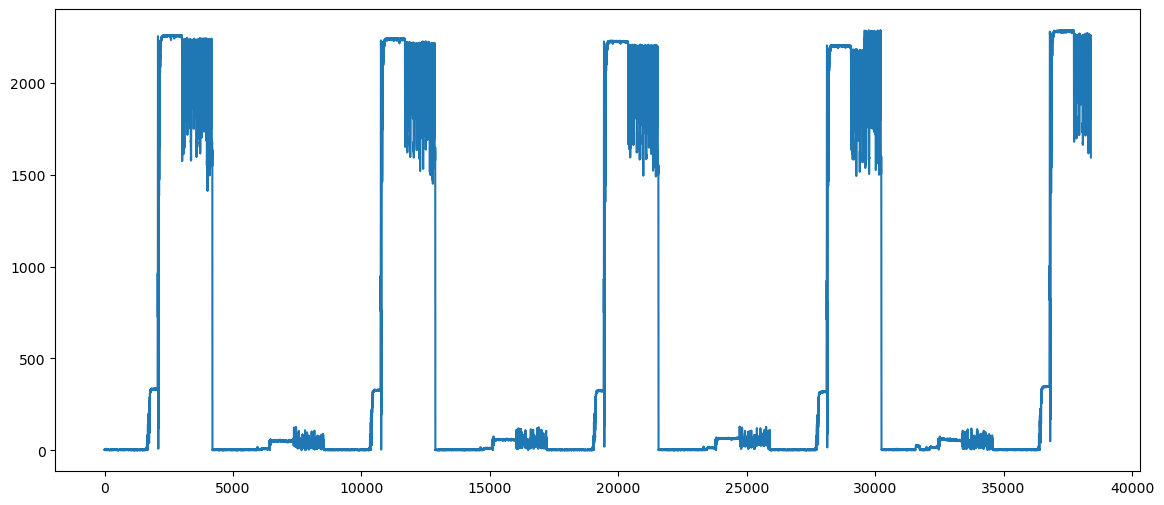

In [51]:
x = ch_2405 #+ ch_2450
# x = ch_2450

L = 4 #16 # Window Length; Samples
h = np.ones(L)/L # filter coefficients

x_filt = np.convolve(x, h, mode="same")
# mag_filt = np.convolve(mag, h, mode="same")


fig_size = (14, 6)
plt.figure(figsize=fig_size)
plt.plot(np.abs(x_filt))

In [52]:
samp_rate = 1.92e6
Fs = samp_rate

dphi = np.angle(iq[1:] * np.conj(iq[:-1]))   # in (-pi, pi]
# instantaneous frequency includes Carrier Frequency Offset
inst_freq = (Fs/(2*np.pi)) * dphi  
cfo = np.mean(inst_freq)
print("CFO = {:.1f} kHz".format(cfo/1000))
print("Subtracting CFO from f_inst")

# Subtract CFO
inst_freq -= cfo

CFO = -16.7 kHz
Subtracting CFO from f_inst


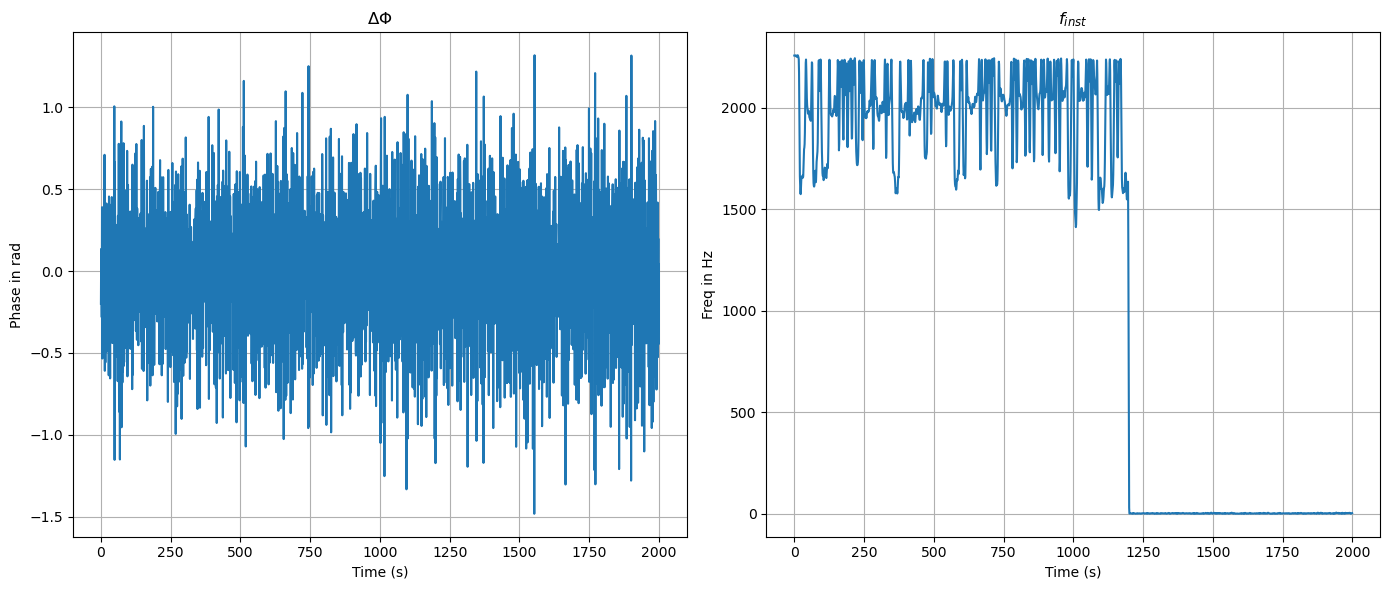

In [57]:
start = 3000
end = 5000

fig_size = (14, 6)
marker_size = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)

# Left subplot: IQ
ax1.plot(dphi[start:end], '-', markersize=marker_size)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Phase in rad")
ax1.set_title("$\Delta\Phi$")
ax1.grid(True)

# Right subplot: Magnitude
# ax2.plot(inst_freq[start:end], '-')
# ax2.set_xlabel("Time (s)")
# ax2.set_ylabel("Freq in Hz")
# ax2.set_title("$f_{inst}$")
# ax2.grid(True)

ax2.plot(np.abs(x_filt)[start:end], '-')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Freq in Hz")
ax2.set_title("$f_{inst}$")
ax2.grid(True)


plt.tight_layout()
plt.show()

In [55]:
# Filter
L = 16*1 #16 # Window Length; Samples
h = np.ones(L)/L # filter coefficients

dphi_filt = np.convolve(dphi, h, mode="same")
inst_freq_filt = np.convolve(inst_freq, h, mode="same")

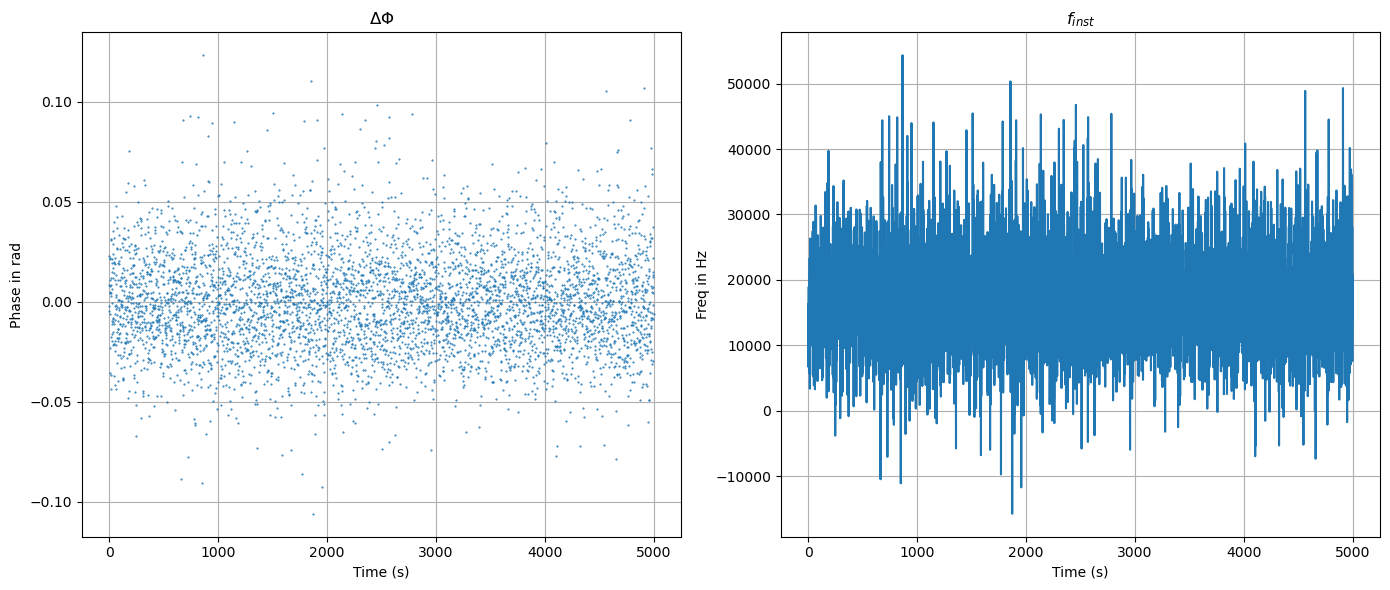

In [56]:
fig_size = (14, 6)
marker_size = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)

# Left subplot: IQ
ax1.plot(dphi_filt[start:end], '.', markersize=marker_size)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Phase in rad")
ax1.set_title("$\Delta\Phi$")
ax1.grid(True)

# Right subplot: Magnitude
ax2.plot(inst_freq_filt[start:end], '-')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Freq in Hz")
ax2.set_title("$f_{inst}$")
ax2.grid(True)

plt.tight_layout()
plt.show()

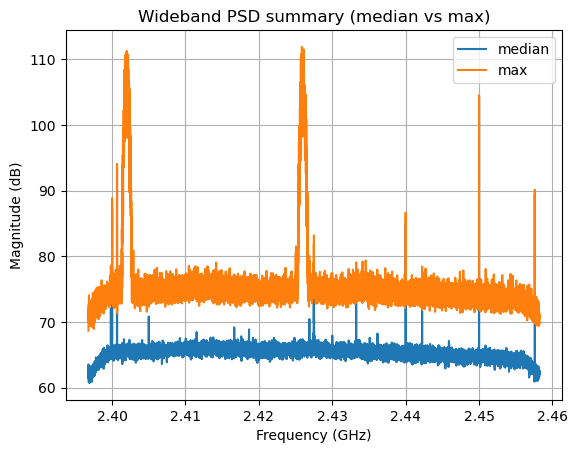

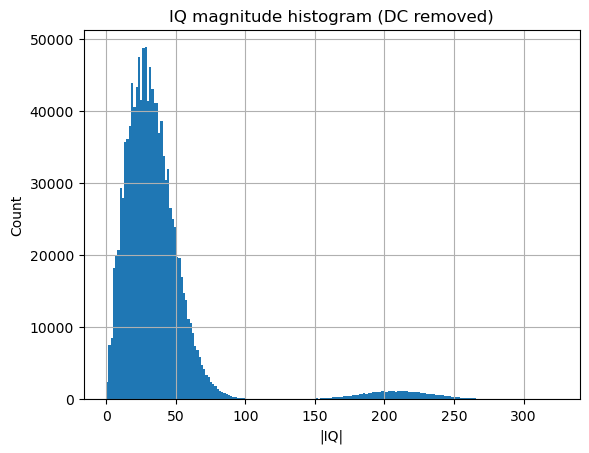

In [9]:
# iq, ch1, ch2, fs_out, meta = pluto_capture_two_rf_channels_time_coherent(
#     num_samples=num_samples,
#     chunk=262144,
# )

fs_in = meta["fs_in_hz"]
lo_hz = meta["lo_hz"]

# plot_waterfall(
#     iq,
#     fs_hz=fs_in,
#     lo_hz=lo_hz,                 # absolute GHz axis
#     nfft=4096,
#     title="Waterfall (full wideband capture)"
# )

plot_psd_summary(
    iq,
    fs_hz=fs_in,
    lo_hz=lo_hz,
    nfft=16384,
    title="Wideband PSD summary (median vs max)"
)

plot_power_histogram(iq)


In [34]:
import numpy as np

def remove_dc(x):
    return x - np.mean(x)

def power_db(x):
    x = remove_dc(x)
    return 10*np.log10(np.mean(np.abs(x)**2) + 1e-15)

def quick_psd_peak(x, fs, nfft=16384):
    x = remove_dc(x)
    n = min(len(x), nfft)
    w = np.hanning(n)
    X = np.fft.fftshift(np.fft.fft(x[:n] * w, n=n))
    P = 20*np.log10(np.abs(X) + 1e-12)
    f = np.fft.fftshift(np.fft.fftfreq(n, d=1/fs))
    i = np.argmax(P)
    return f[i], P[i]

p1 = power_db(ch_2405)
p2 = power_db(ch_2450)
print("DC-removed power (dB): 2405 =", p1, "2450 =", p2)

fpk1, pk1 = quick_psd_peak(ch_2405, fs_out)
fpk2, pk2 = quick_psd_peak(ch_2450, fs_out)
print(f"2405 peak at {fpk1/1e3:.1f} kHz, level {pk1:.1f} dB")
print(f"2450 peak at {fpk2/1e3:.1f} kHz, level {pk2:.1f} dB")


DC-removed power (dB): 2405 = -0.078350075 2450 = 8.088727
2405 peak at -93.5 kHz, level 49.2 dB
2450 peak at -688.6 kHz, level 77.7 dB


# New Processing

In [1]:
import numpy as np

def design_lowpass_fir(cutoff_hz, fs_hz, num_taps=513, window="hann"):
    n = np.arange(num_taps, dtype=np.float64)
    m = (num_taps - 1) / 2.0
    fc = cutoff_hz / fs_hz
    h = 2.0 * fc * np.sinc(2.0 * fc * (n - m))

    if window == "hann":
        w = 0.5 - 0.5 * np.cos(2.0 * np.pi * n / (num_taps - 1))
    elif window == "hamming":
        w = 0.54 - 0.46 * np.cos(2.0 * np.pi * n / (num_taps - 1))
    else:
        raise ValueError("window must be 'hann' or 'hamming'")
    h *= w
    h /= np.sum(h)
    return h

def ddc_extract_clean(iq, fs_hz, f_offset_hz, decim=16, cutoff_hz=900_000, fir_taps=513):
    iq = np.asarray(iq)
    n = np.arange(iq.size, dtype=np.float64)
    t = n / float(fs_hz)

    # mix to DC
    mixed = iq * np.exp(-1j * 2.0 * np.pi * float(f_offset_hz) * t)

    # strong anti-alias LPF
    h = design_lowpass_fir(cutoff_hz=cutoff_hz, fs_hz=fs_hz, num_taps=fir_taps)
    filt = np.convolve(mixed, h.astype(np.complex128), mode="same")

    # decimate
    y = filt[::decim].astype(np.complex64)
    return y, fs_hz / decim


In [3]:
# For your GFSK:
# decim 16 -> fs_out 3.84 MS/s, cutoff 0.9 MHz (keeps the symbol shaping)
# ch_2405, fs_out = ddc_extract_clean(iq, sample_rate, off1, decim=16, cutoff_hz=900_000, fir_taps=513)
# ch_2450, _      = ddc_extract_clean(iq, sample_rate, off2, decim=16, cutoff_hz=900_000, fir_taps=513)


In [13]:
# ----------------------------
# Wideband capture + 2 channels
# ----------------------------
import numpy as np
import adi
def pluto_capture_two_rf_channels_time_coherent(
    uri="ip:pluto.local",
    f1_hz=2.405e9,
    f2_hz=2.450e9,
    sample_rate=61_440_000,       # try 61.44 MS/s
    rf_bandwidth=56_000_000,      # try ~50–56 MHz (must be supported by your build)
    gain_mode="manual",
    gain_db=20,
    num_samples=2_000_000,        # wideband: keep modest unless you know your link can stream more
    warmup_reads=2,
    chunk=262144,
    out_bw_hz=2_000_000,          # extracted channel BW (Hz) per subchannel
    decim=32,                     # 61.44e6 / 32 = 1.92 MS/s output
):
    """
    Captures ONE wideband IQ recording, then extracts two RF channels (f1, f2)
    with coherent time alignment.

    Returns:
      ch1_iq, ch2_iq, fs_out, meta
    """
    # Center LO midway
    lo_hz = 0.5 * (f1_hz + f2_hz)
    # lo_hz = f1_hz
    # lo_hz = 103e6

    # Offsets of each RF channel relative to LO (these are what appear in baseband)
    off1 = f1_hz - lo_hz  # e.g. 2.405 - 2.4275 = -22.5 MHz
    off2 = f2_hz - lo_hz  # e.g. +22.5 MHz

    sdr = adi.Pluto(uri)

    # Single RX is enough for this frequency-coherent two-channel extraction
    # (You can also enable both RX channels if you want spatial info too.)
    sdr.rx_enabled_channels = [0]

    sdr.rx_lo = int(lo_hz)
    sdr.sample_rate = int(sample_rate)
    sdr.rx_rf_bandwidth = int(rf_bandwidth)

    sdr.gain_control_mode_chan0 = gain_mode
    if gain_mode == "manual":
        sdr.rx_hardwaregain_chan0 = float(gain_db)

    sdr.rx_buffer_size = int(chunk)

    for _ in range(warmup_reads):
        _ = sdr.rx()

    # Capture wideband IQ
    iq = np.empty(num_samples, dtype=np.complex64)
    got = 0
    while got < num_samples:
        x = sdr.rx()
        x = np.asarray(x).astype(np.complex64, copy=False)

        # If somehow returns multi-chan, take chan0
        if x.ndim > 1:
            x = x[0]

        n = min(x.size, num_samples - got)
        iq[got:got+n] = x[:n]
        got += n

    print("Capture done.")
    
    # Extract two subchannels from the SAME iq stream (time-coherent)
    # ch1, fs_out = ddc_extract(iq, fs_hz=sample_rate, f_offset_hz=off1, out_bw_hz=out_bw_hz, decim=decim)
    # ch2, _      = ddc_extract(iq, fs_hz=sample_rate, f_offset_hz=off2, out_bw_hz=out_bw_hz, decim=decim)
    ch1, fs_out = ddc_extract_clean(iq, sample_rate, off1, decim=decim, cutoff_hz=900_000, fir_taps=513)
    ch2, _      = ddc_extract_clean(iq, sample_rate, off2, decim=decim, cutoff_hz=900_000, fir_taps=513)

    meta = {
        "lo_hz": lo_hz,
        "f1_hz": f1_hz,
        "f2_hz": f2_hz,
        "offset1_hz": off1,
        "offset2_hz": off2,
        "fs_in_hz": sample_rate,
        "fs_out_hz": fs_out,
        "rf_bandwidth_hz": rf_bandwidth,
        "decim": decim,
        "out_bw_hz": out_bw_hz,
    }
    return iq, ch1, ch2, fs_out, meta

In [14]:
sample_rate = 61_440_000
sample_time = 0.020 #0.100
num_samples = int(sample_rate * sample_time)
print(num_samples)

1228800


In [15]:
for i in range(20,25):
    print("2^{} = {:,} kB".format(i, 2**i/1024))

2^20 = 1,024.0 kB
2^21 = 2,048.0 kB
2^22 = 4,096.0 kB
2^23 = 8,192.0 kB
2^24 = 16,384.0 kB


In [18]:
if __name__ == "__main__":
    iq, ch1, ch2, fs_out, meta = pluto_capture_two_rf_channels_time_coherent(
        uri="ip:pluto.local",
        f1_hz=2.405e9,
        f2_hz=2.450e9,
        sample_rate=61_440_000,
        rf_bandwidth=56_000_000,
        # rf_bandwidth=10_000_000,
        gain_mode="manual",
        gain_db=10,
        num_samples=num_samples,
        # out_bw_hz=2_000_000,
        out_bw_hz=3_000_000,
        decim=16, #32,                # fs_out = 1.92 MS/s
        # chunk=1_048_576  #524288
        chunk=int(2**22) # 2**24 is the limit
    )

    print("Output sample rate:", fs_out)
    print("ch1:", ch1.shape, ch1.dtype)
    print("ch2:", ch2.shape, ch2.dtype)
    print("meta:", meta)

    # Simple sanity check: compute rough power in each extracted channel
    p1 = 10*np.log10(np.mean(np.abs(ch1)**2) + 1e-12)
    p2 = 10*np.log10(np.mean(np.abs(ch2)**2) + 1e-12)
    print("Power dBFS-ish (relative): 2405 =", p1, "2450 =", p2)

Capture done.
Output sample rate: 3840000.0
ch1: (76800,) complex64
ch2: (76800,) complex64
meta: {'lo_hz': 2427500000.0, 'f1_hz': 2405000000.0, 'f2_hz': 2450000000.0, 'offset1_hz': -22500000.0, 'offset2_hz': 22500000.0, 'fs_in_hz': 61440000, 'fs_out_hz': 3840000.0, 'rf_bandwidth_hz': 56000000, 'decim': 16, 'out_bw_hz': 3000000}
Power dBFS-ish (relative): 2405 = 33.00582 2450 = 34.028645


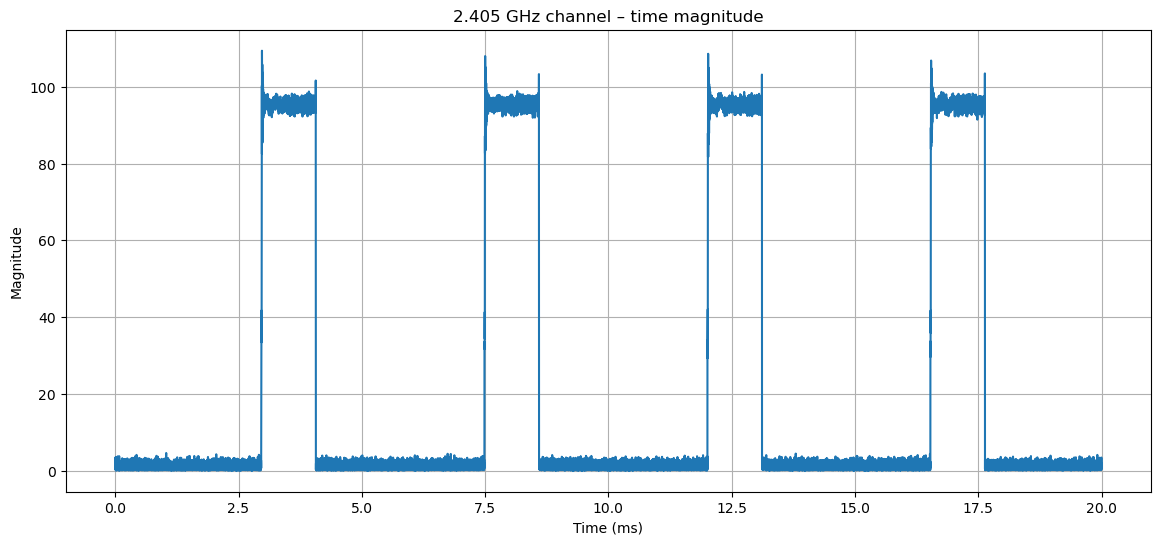

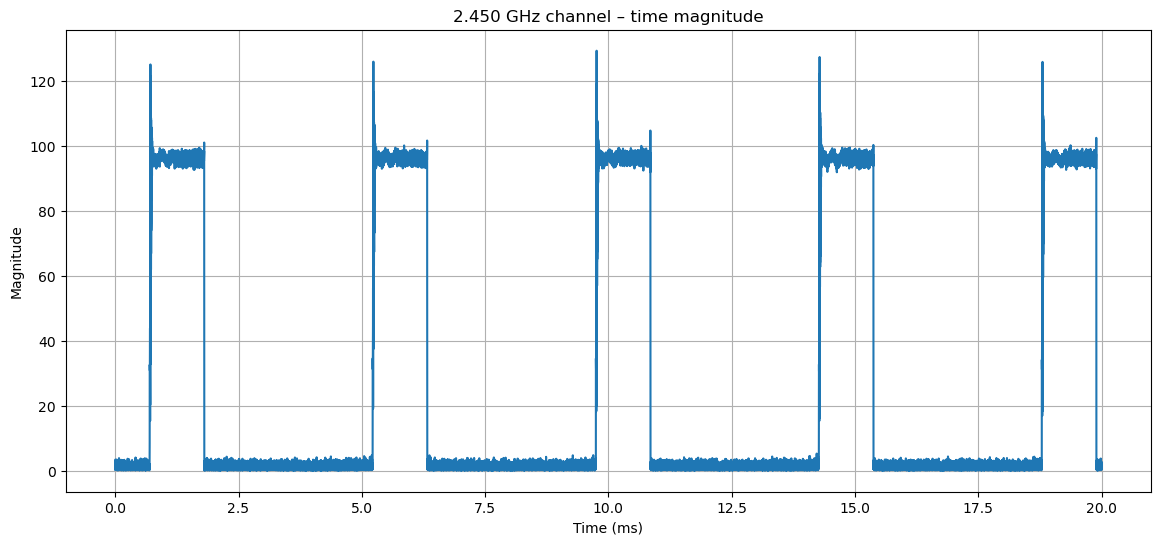

In [20]:
import numpy as np
import matplotlib.pyplot as plt

def plot_time_magnitude(x, fs, title):
    t = np.arange(len(x)) / fs
    mag = np.abs(x - np.mean(x))
    
    fig_size = (14, 6)
    plt.figure(figsize=fig_size)
    plt.plot(t * 1e3, mag)
    plt.xlabel("Time (ms)")
    plt.ylabel("Magnitude")
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_time_magnitude(ch1, fs_out, "2.405 GHz channel – time magnitude")
plot_time_magnitude(ch2, fs_out, "2.450 GHz channel – time magnitude")

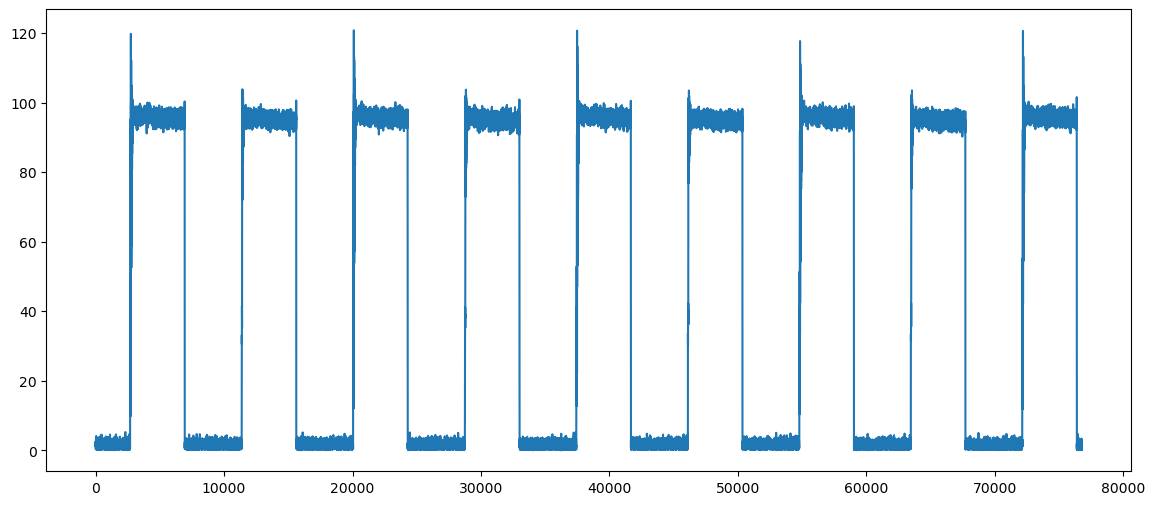

In [27]:
x = ch1 + ch2
# x = ch_2450

L = 2 # Window Length; Samples
h = np.ones(L)/L # filter coefficients

x_filt = np.convolve(x, h, mode="same")
# mag_filt = np.convolve(mag, h, mode="same")


fig_size = (14, 6)
plt.figure(figsize=fig_size)
plt.plot(np.abs(x_filt))

In [28]:
samp_rate = 1.92e6
Fs = samp_rate

dphi = np.angle(iq[1:] * np.conj(iq[:-1]))   # in (-pi, pi]
# instantaneous frequency includes Carrier Frequency Offset
inst_freq = (Fs/(2*np.pi)) * dphi  
cfo = np.mean(inst_freq)
print("CFO = {:.1f} kHz".format(cfo/1000))
print("Subtracting CFO from f_inst")

# Subtract CFO
inst_freq -= cfo

CFO = 49.0 kHz
Subtracting CFO from f_inst


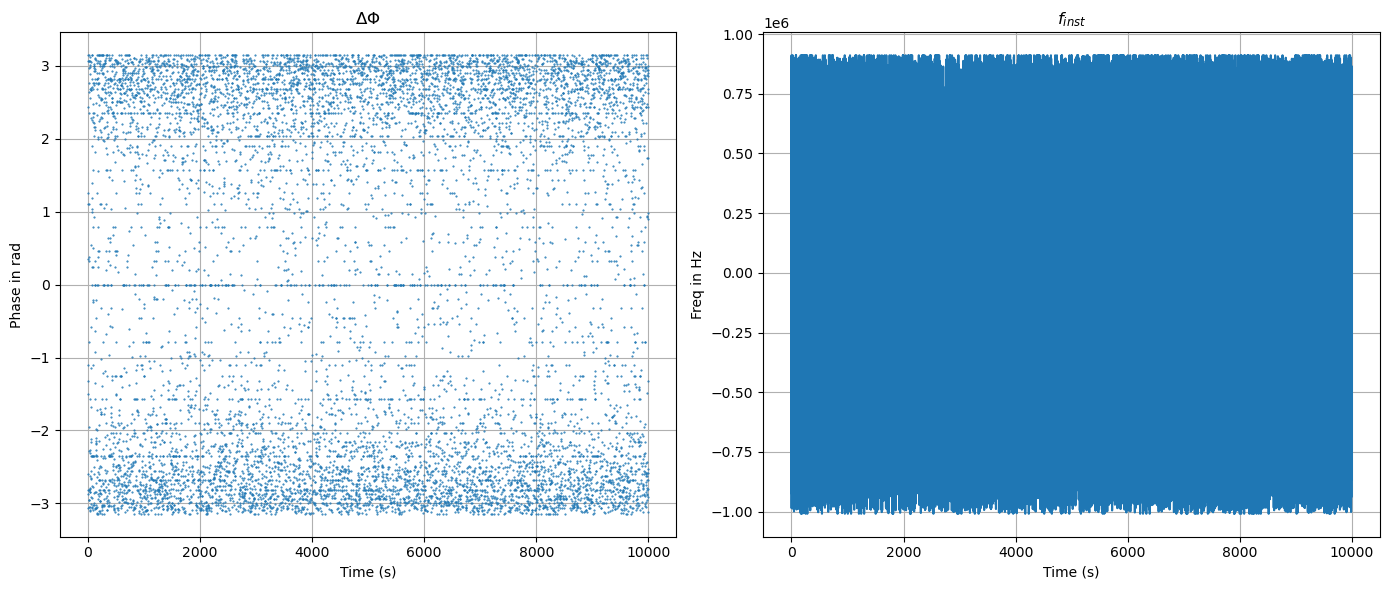

In [39]:
start = 000
end = 10000

fig_size = (14, 6)
marker_size = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)

# Left subplot: IQ
ax1.plot(dphi[start:end], '.', markersize=marker_size)
# ax1.plot(iq[start:end], '.', markersize=marker_size)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Phase in rad")
ax1.set_title("$\Delta\Phi$")
ax1.grid(True)

# Right subplot: Magnitude
ax2.plot(inst_freq[start:end], '-')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Freq in Hz")
ax2.set_title("$f_{inst}$")
ax2.grid(True)

# ax2.plot(np.abs(x_filt)[start:end], '-')
# ax2.set_xlabel("Time (s)")
# ax2.set_ylabel("Freq in Hz")
# ax2.set_title("$f_{inst}$")
# ax2.grid(True)


plt.tight_layout()
plt.show()

In [32]:
# Filter
L = 2 # Window Length; Samples
h = np.ones(L)/L # filter coefficients

dphi_filt = np.convolve(dphi, h, mode="same")
inst_freq_filt = np.convolve(inst_freq, h, mode="same")

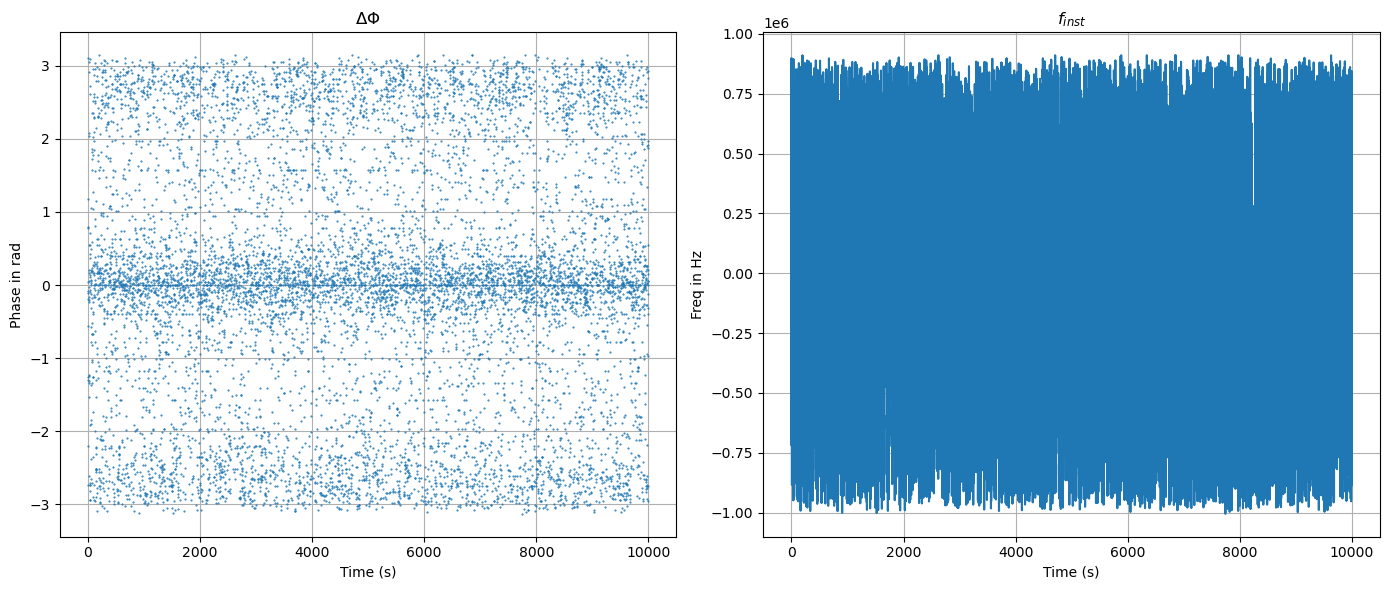

In [33]:
fig_size = (14, 6)
marker_size = 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=fig_size)

# Left subplot: IQ
ax1.plot(dphi_filt[start:end], '.', markersize=marker_size)
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Phase in rad")
ax1.set_title("$\Delta\Phi$")
ax1.grid(True)

# Right subplot: Magnitude
ax2.plot(inst_freq_filt[start:end], '-')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Freq in Hz")
ax2.set_title("$f_{inst}$")
ax2.grid(True)

plt.tight_layout()
plt.show()

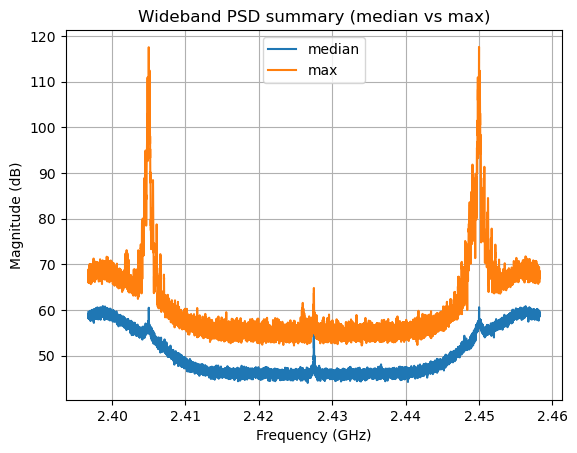

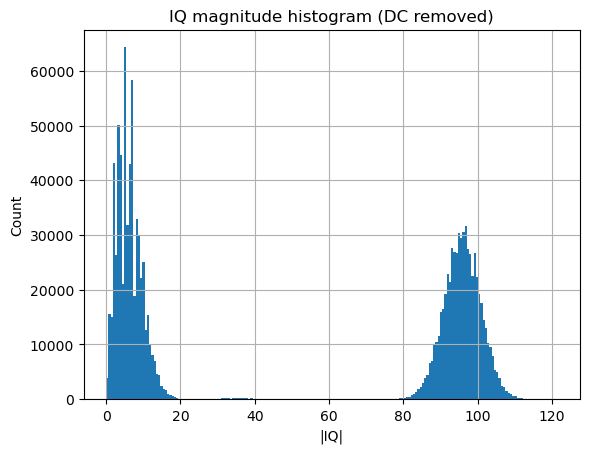

In [37]:
# iq, ch1, ch2, fs_out, meta = pluto_capture_two_rf_channels_time_coherent(
#     num_samples=num_samples,
#     chunk=262144,
# )

fs_in = meta["fs_in_hz"]
lo_hz = meta["lo_hz"]

plot_psd_summary(
    iq,
    fs_hz=fs_in,
    lo_hz=lo_hz,
    nfft=16384,
    title="Wideband PSD summary (median vs max)"
)

plot_power_histogram(iq)
